In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd

In [6]:
df = pd.read_csv('cleaned_dataset.csv', encoding='latin-1')

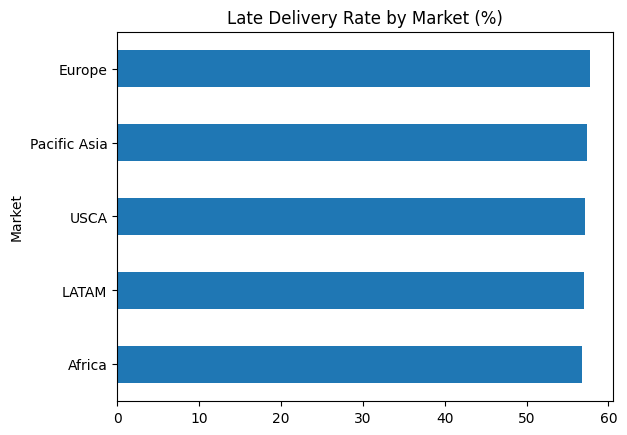

In [7]:
# 1. Late Delivery Rate by Market
late_by_market = df.groupby('Market')['is_late'].mean() * 100
late_by_market.sort_values().plot(kind='barh', title='Late Delivery Rate by Market (%)')
plt.show()

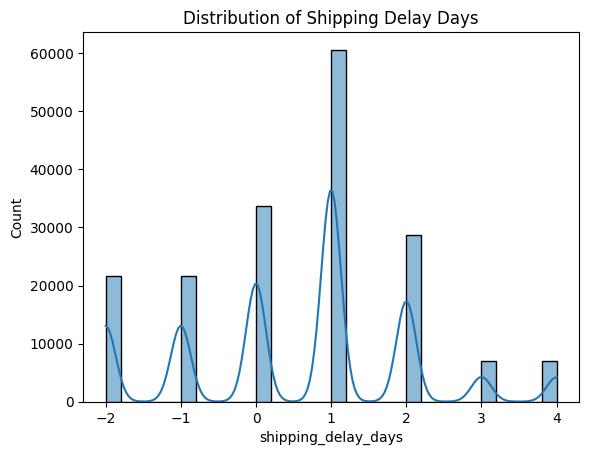

In [8]:
# 2. Shipping Delay Distribution
sns.histplot(df['shipping_delay_days'], bins=30, kde=True)
plt.title('Distribution of Shipping Delay Days')
plt.show()

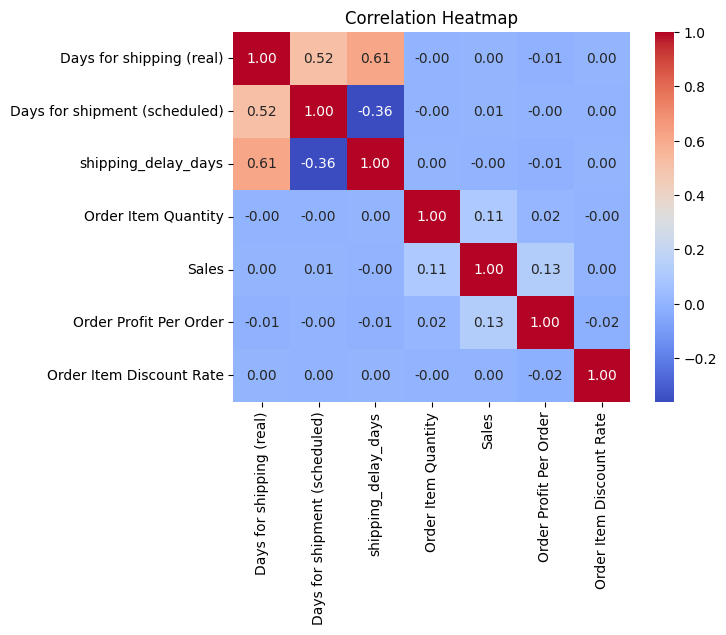

In [9]:
# 3. Correlation Heatmap
cols = ['Days for shipping (real)', 'Days for shipment (scheduled)',
        'shipping_delay_days', 'Order Item Quantity',
        'Sales', 'Order Profit Per Order', 'Order Item Discount Rate']
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [10]:
# 4. T-Test: Do cancelled orders have significantly lower profit?
cancelled = df[df['is_cancelled'] == 1]['Order Profit Per Order']
not_cancelled = df[df['is_cancelled'] == 0]['Order Profit Per Order']
t_stat, p_value = stats.ttest_ind(cancelled, not_cancelled)
print(f"T-Test: t={t_stat:.4f}, p={p_value:.4f}")
print("Significant difference" if p_value < 0.05 else "No significant difference")

T-Test: t=-0.9213, p=0.3569
No significant difference


In [11]:
# 5. Chi-Square Test: Is Shipping Mode related to Late Delivery?
contingency = pd.crosstab(df['Shipping Mode'], df['Delivery Status'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-Square: chi2={chi2:.2f}, p={p:.4f}")
print("Shipping Mode IS related to Delivery Status" if p < 0.05 else "No relationship")


Chi-Square: chi2=55782.48, p=0.0000
Shipping Mode IS related to Delivery Status


In [12]:
# 6. Revenue Lost to Cancellations by Year
revenue_lost = df[df['is_cancelled'] == 1].groupby('order_year')['Sales'].sum()
print("Revenue lost per year:\n", revenue_lost)

Revenue lost per year:
 order_year
2015    255714.984895
2016    242983.134952
2017    237882.354196
2018      7789.930078
Name: Sales, dtype: float64


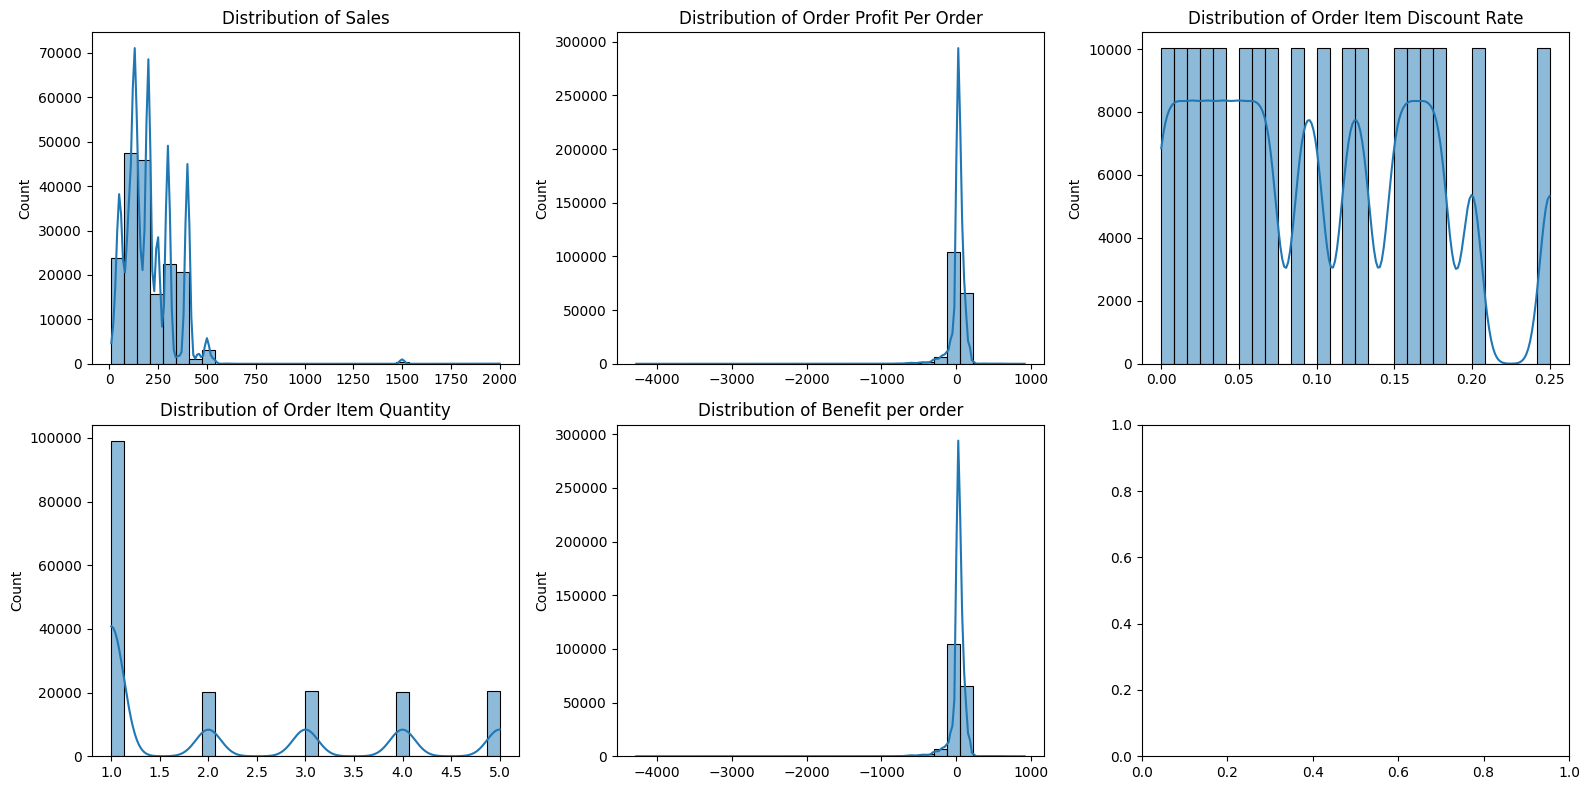

In [13]:
cols = ['Sales', 'Order Profit Per Order', 'Order Item Discount Rate', 
        'Order Item Quantity', 'Benefit per order']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('univariate_distribution.png', dpi=150)
plt.show()

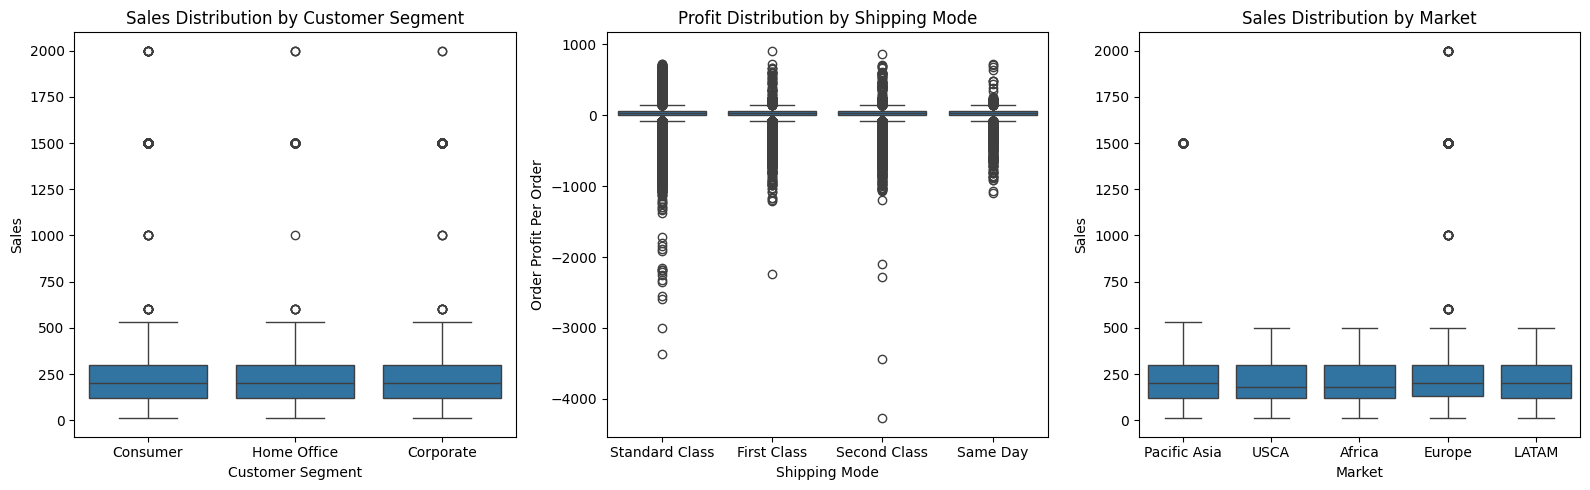

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x='Customer Segment', y='Sales', ax=axes[0])
axes[0].set_title('Sales Distribution by Customer Segment')

sns.boxplot(data=df, x='Shipping Mode', y='Order Profit Per Order', ax=axes[1])
axes[1].set_title('Profit Distribution by Shipping Mode')

sns.boxplot(data=df, x='Market', y='Sales', ax=axes[2])
axes[2].set_title('Sales Distribution by Market')

plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=150)
plt.show()


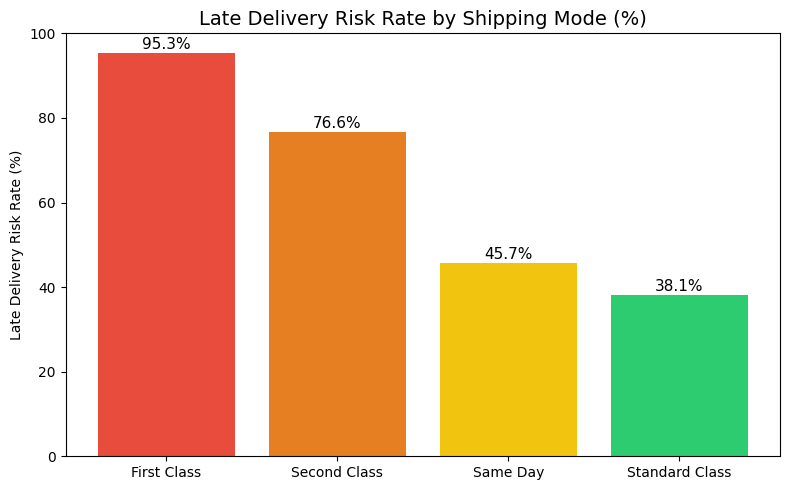

In [15]:
late_by_mode = df.groupby('Shipping Mode')['Late_delivery_risk'].mean() * 100
late_by_mode = late_by_mode.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(late_by_mode.index, late_by_mode.values, color=['#e74c3c','#e67e22','#f1c40f','#2ecc71'])
plt.title('Late Delivery Risk Rate by Shipping Mode (%)', fontsize=14)
plt.ylabel('Late Delivery Risk Rate (%)')
plt.ylim(0, 100)

for bar, val in zip(bars, late_by_mode.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('late_delivery_by_mode.png', dpi=150)
plt.show()

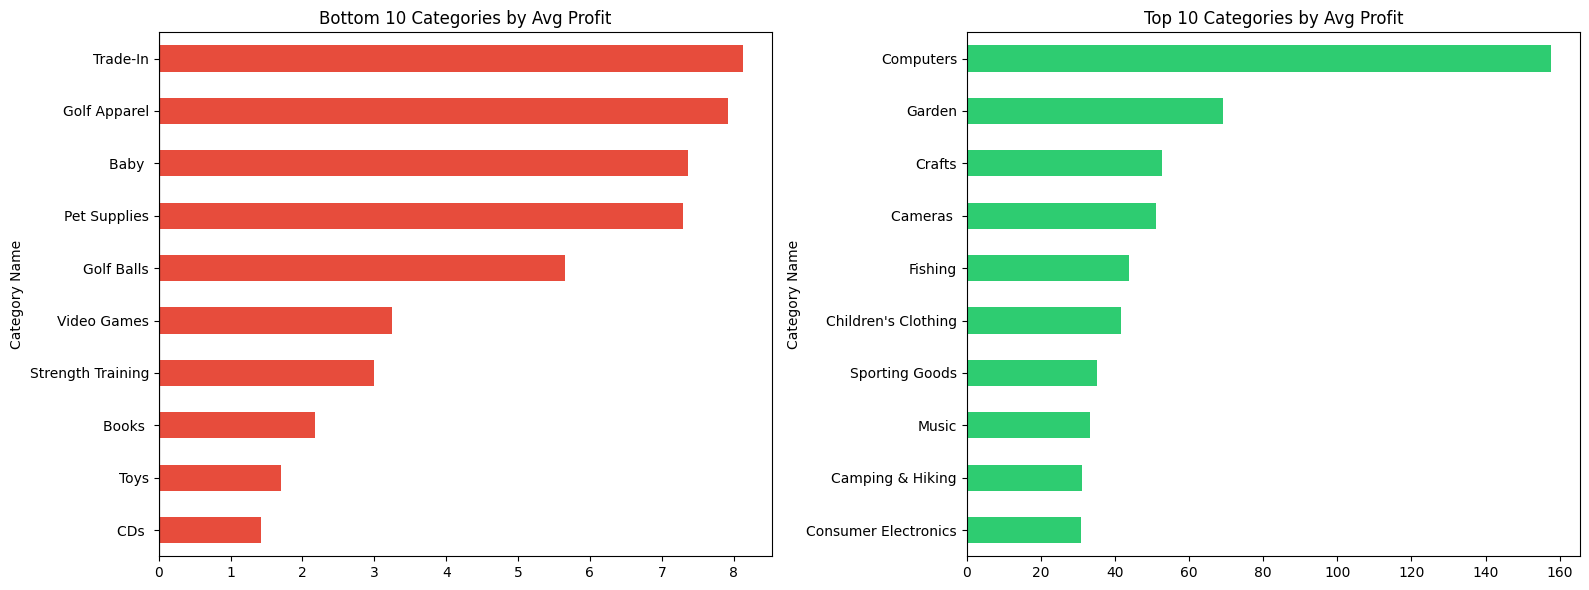

In [16]:
category_profit = df.groupby('Category Name')['Order Profit Per Order'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bottom 10 — Loss making
category_profit.head(10).plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('Bottom 10 Categories by Avg Profit')
axes[0].axvline(0, color='black', linewidth=0.8)

# Top 10 — Most profitable
category_profit.tail(10).plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Top 10 Categories by Avg Profit')

plt.tight_layout()
plt.savefig('category_profit.png', dpi=150)
plt.show()

C:\Users\ssidd\AppData\Local\Temp\ipykernel_26384\3427339672.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['order_date'] = pd.to_datetime(df['order date (DateOrders)'])


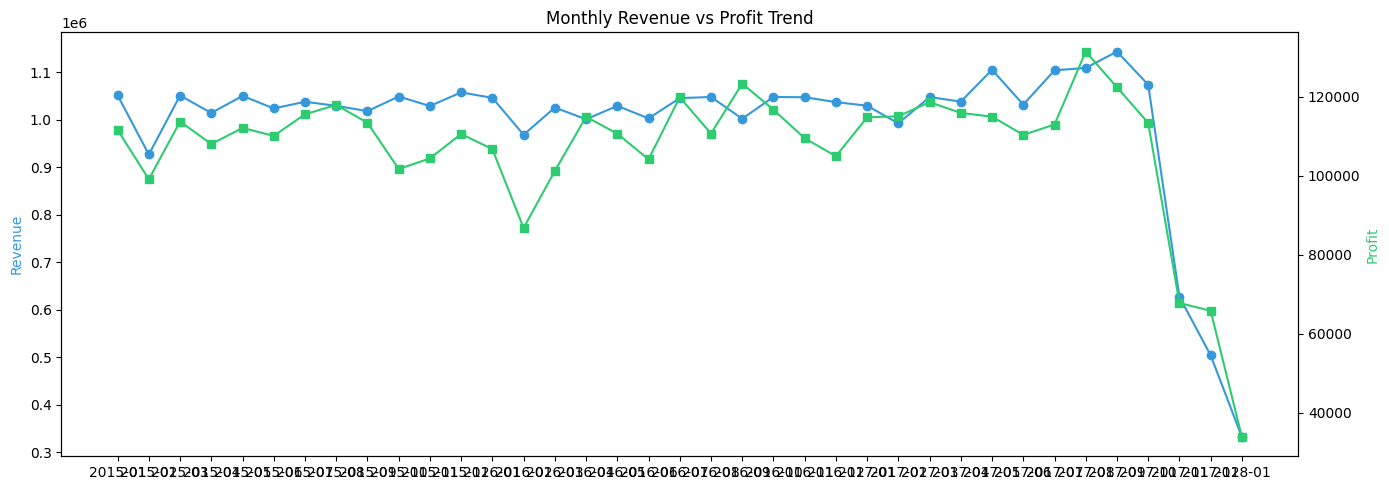

In [17]:
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'])
df['order_month'] = df['order_date'].dt.to_period('M')

monthly = df.groupby('order_month').agg(
    revenue=('Sales', 'sum'),
    profit=('Order Profit Per Order', 'sum'),
    orders=('Order Id', 'count')
).reset_index()

monthly['order_month'] = monthly['order_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(monthly['order_month'], monthly['revenue'], color='#3498db', marker='o', label='Revenue')
ax2.plot(monthly['order_month'], monthly['profit'], color='#2ecc71', marker='s', label='Profit')

ax1.set_ylabel('Revenue', color='#3498db')
ax2.set_ylabel('Profit', color='#2ecc71')
ax1.set_title('Monthly Revenue vs Profit Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()

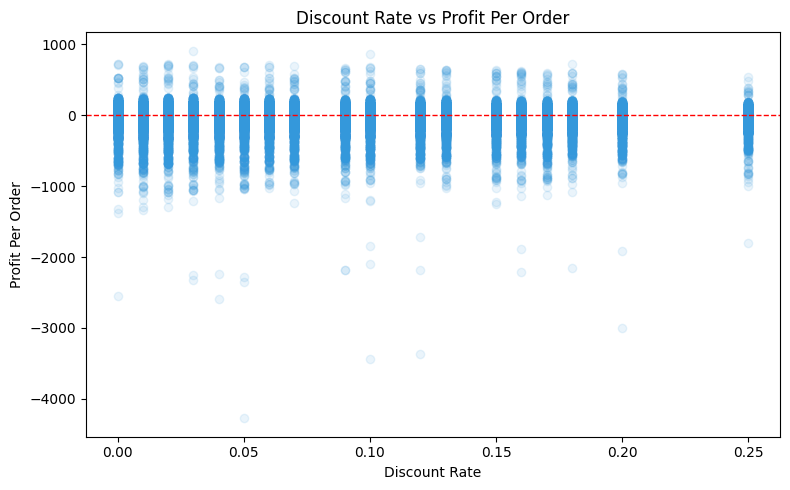

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Order Item Discount Rate'], df['Order Profit Per Order'], 
            alpha=0.1, color='#3498db')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Discount Rate')
plt.ylabel('Profit Per Order')
plt.title('Discount Rate vs Profit Per Order')
plt.tight_layout()
plt.savefig('discount_vs_profit.png', dpi=150)
plt.show()

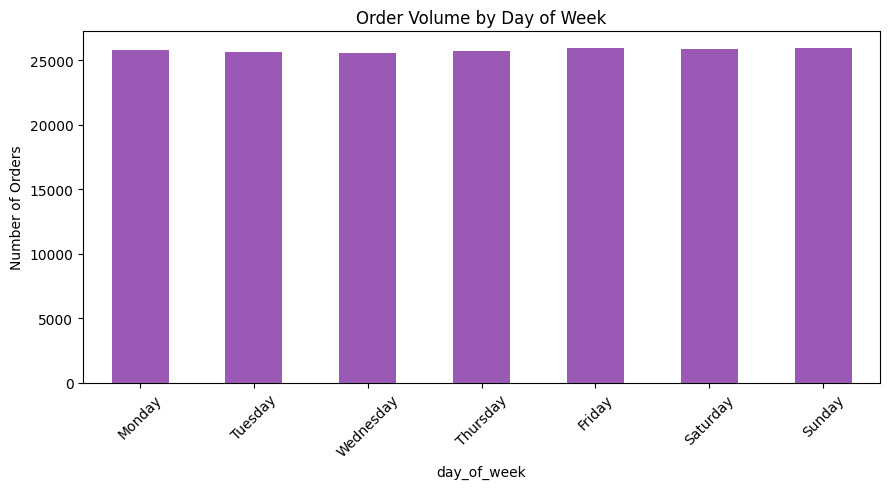

In [19]:
df['day_of_week'] = df['order_date'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

day_counts = df.groupby('day_of_week')['Order Id'].count().reindex(day_order)

plt.figure(figsize=(9, 5))
day_counts.plot(kind='bar', color='#9b59b6')
plt.title('Order Volume by Day of Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('orders_by_day.png', dpi=150)
plt.show()

In [20]:
from scipy import stats

markets = df['Market'].unique()
market_groups = [df[df['Market'] == m]['Order Profit Per Order'] for m in markets]

f_stat, p_value = stats.f_oneway(*market_groups)
print(f"One-Way ANOVA: F={f_stat:.4f}, p={p_value:.4f}")
print("Market DOES significantly affect profit" if p_value < 0.05 else "No significant difference across markets")

One-Way ANOVA: F=3.3412, p=0.0096
Market DOES significantly affect profit


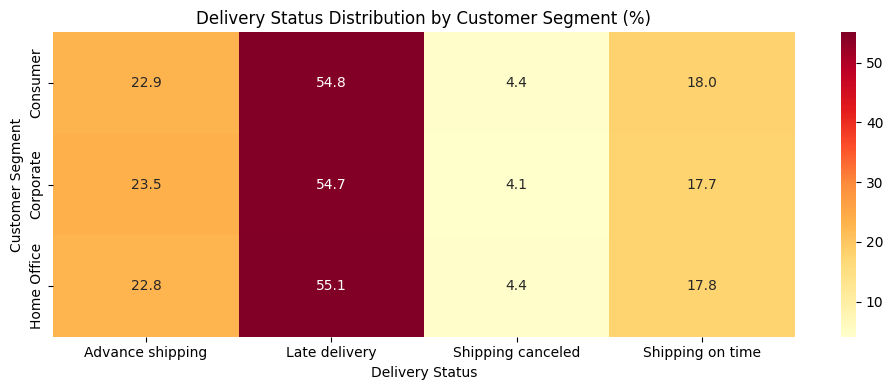

In [21]:
pivot = pd.crosstab(df['Customer Segment'], df['Delivery Status'], normalize='index') * 100

plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Delivery Status Distribution by Customer Segment (%)')
plt.tight_layout()
plt.savefig('segment_delivery_heatmap.png', dpi=150)
plt.show()
# Shows if certain segments experience more late deliveries

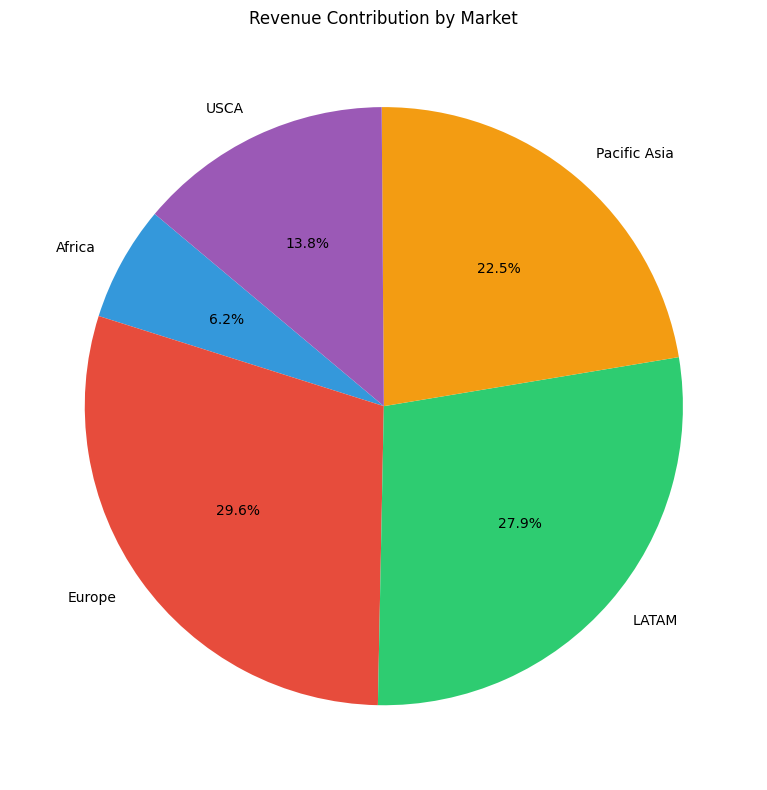

In [22]:
market_revenue = df.groupby('Market')['Sales'].sum()

plt.figure(figsize=(8, 8))
plt.pie(market_revenue.values, labels=market_revenue.index, 
        autopct='%1.1f%%', startangle=140,
        colors=['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6'])
plt.title('Revenue Contribution by Market')
plt.tight_layout()
plt.savefig('revenue_by_market.png', dpi=150)
plt.show()